In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern, mismo look que LaTeX

In [3]:

# Read the file: one line per instance
with open("../data/many_runs_regularized.txt", "r") as f:
    lines = f.readlines()

# Parse each line into its own (time, mRNA, protein) arrays
time_list, mRNA_list, protein_list = [], [], []
for line in lines:
    values = np.array(line.split(), dtype=float)
    time_list.append(values[0::3])
    mRNA_list.append(values[1::3])
    protein_list.append(values[2::3])



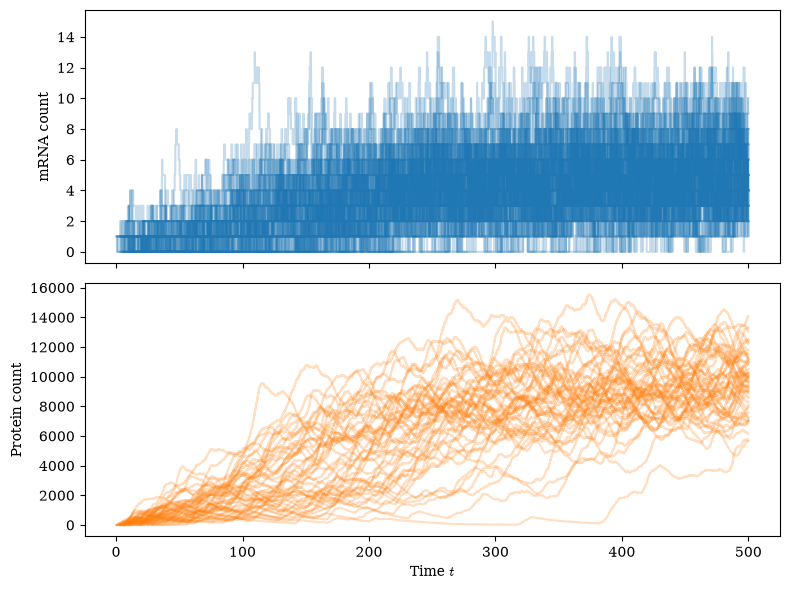

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

for i in range(len(lines)):
    ax[0].step(time_list[i], mRNA_list[i], where='post', color='tab:blue', alpha=0.25)
    ax[1].step(time_list[i], protein_list[i], where='post', color='tab:orange', alpha=0.25)

ax[0].set_ylabel(r"mRNA count")
ax[1].set_ylabel(r"Protein count")
ax[1].set_xlabel(r"Time $t$")

plt.tight_layout()
#plt.savefig("../figures/50_runs.pdf")
plt.show()

In [4]:
print("Number of simulations:", len(lines))

Number of simulations: 50


In [5]:
#The dimensions are heterogeneous, so we need to fill the data into a common time grid to calculate mean and standard deviation.
#to do this we coarse grain the time grid to a fixed number of time points.
number_of_time_points = 10000
time_coarse = np.linspace(0, 500, number_of_time_points) #coarse grained time grid
resampled_mRNA = np.zeros((len(lines), number_of_time_points))
resampled_protein = np.zeros((len(lines), number_of_time_points))  

#and we fill the resampled arrays using using the last known value for each time point (step function behavior).

for i in range(len(lines)):
    resampled_mRNA[i] = mRNA_list[i][np.searchsorted(time_list[i], time_coarse, side='right') - 1]
    resampled_protein[i] = protein_list[i][np.searchsorted(time_list[i], time_coarse, side='right') - 1]    



In [6]:
#Now with common times we can calculate the mean and standard deviation across all simulations for each time point.
mean_mRNA = np.mean(resampled_mRNA, axis=0)
std_mRNA = np.std(resampled_mRNA, axis=0)
mean_protein = np.mean(resampled_protein, axis=0)
std_protein = np.std(resampled_protein, axis=0) 

In [ ]:
#and graph over time the mean and the standard deviation

plt.figure(figsize=(10, 6))
plt.plot(time_coarse, mean_mRNA, label='Mean mRNA')
plt.fill_between(
    time_coarse,
    mean_mRNA - std_mRNA,
    mean_mRNA + std_mRNA,
    color='blue',
    alpha=0.2,
    label='Std Dev mRNA'
)
plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Mean and Standard Deviation of mRNA Counts Over Time')
plt.legend()
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (744944352.py, line 5)

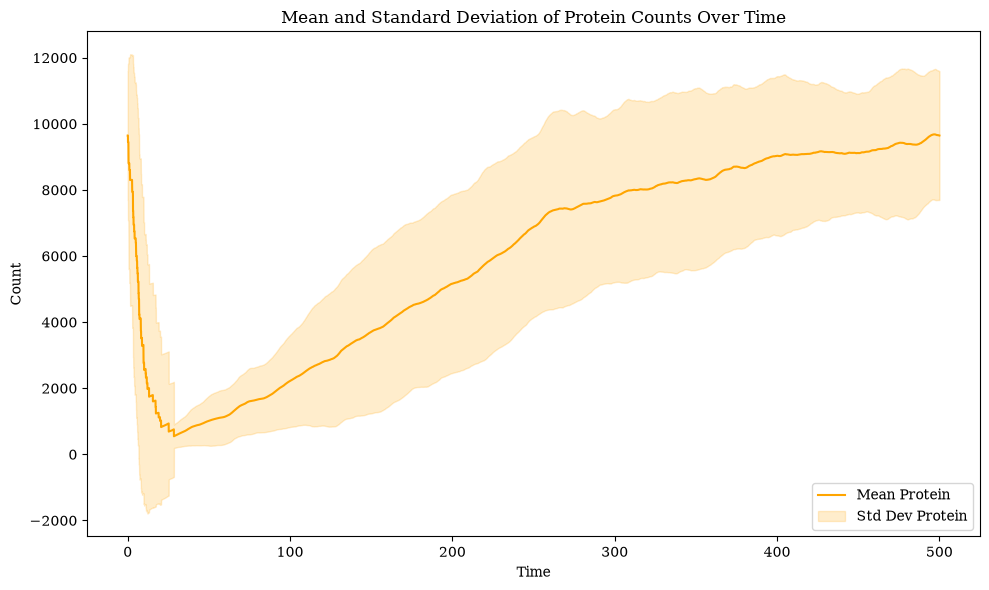

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(time_coarse, mean_protein, label='Mean Protein', color='orange')
plt.fill_between(time_coarse, mean_protein - std_protein, mean_protein +    std_protein, color='orange', alpha=0.2, label='Std Dev Protein')
plt.xlabel('Time')
plt.ylabel('Count')
plt.title('Mean and Standard Deviation of Protein Counts Over Time')
plt.legend()
plt.tight_layout()
plt.show()